# 第三问：光伏预报与日内购电调整

本文件内嵌输入和核心模型，可独立运行。选择 `cumcm2026` 内核后运行全部单元。

比较00时预报固定计划、每6小时更新、收益触发更新，并重跑减购退费口径敏感性。结果统计2025年2—12月，1月连续预热。时间区间仍暂定为样本前10分钟。主结算为原计划费照付，减购另付50%违约费。

每次仅承诺随后6小时的调整，优化至当日24时；这是一种可行策略限制。计划与实际控制未统一优化，不声称全局最优。

In [2]:
from pathlib import Path
import io,base64,json,time
import numpy as np
import pandas as pd
from scipy.optimize import linprog,milp,Bounds,LinearConstraint
from scipy.sparse import coo_matrix,hstack,vstack,csr_matrix
try:
    from IPython.display import display
except ImportError:
    pass
import matplotlib.pyplot as plt
pd.set_option('display.max_columns',20)
pd.set_option('display.float_format',lambda x:f'{x:,.4f}')
OUT=Path.cwd()/'q3_notebook_results'
OUT.mkdir(exist_ok=True)

## 1. 参数

建议先只修改历史窗口、触发裕量、减购系数与计划末态目标。物理参数沿用题面；代码结构固定为10分钟、6小时承诺。减购系数+0.5表示计划费不退，−0.5表示退原价后扣50%违约费。修改参数后必须重跑，旧报告和Excel不会自动更新。

In [3]:
CONFIG={'interval_minutes': 10, 'charge_efficiency': 0.9, 'discharge_efficiency': 0.9, 'storage_min_kwh': 1200.0, 'storage_max_kwh': 10800.0, 'initial_storage_kwh': 6000.0, 'planned_terminal_kwh': 6000.0, 'max_charge_power_kw': 5000.0, 'max_discharge_power_kw': 5000.0, 'emergency_multiplier': 5.0, 'scenario_days': 28, 'mean_days': 7, 'tolerance': 1e-06, 'adjustment_down_coefficient': 0.5, 'adjustment_up_coefficient': 1.5, 'trigger_margin_yuan': 0.0, 'commitment_slots': 36}
cfg=CONFIG.copy()
METHODS=['forecast00_fixed','forecast_updates','benefit_trigger']
display(pd.DataFrame(list(cfg.items()),columns=['parameter','value']))

,parameter,value
0,interval_minutes,10.0000
1,charge_efficiency,0.9000
2,discharge_efficiency,0.9000
3,storage_min_kwh,"1,200.0000"
4,storage_max_kwh,"10,800.0000"
5,initial_storage_kwh,"6,000.0000"
6,planned_terminal_kwh,"6,000.0000"
7,max_charge_power_kw,"5,000.0000"
8,max_discharge_power_kw,"5,000.0000"
9,emergency_multiplier,5.0000


## 2. 内嵌数据

实际负载、光伏来自附件2，电价来自附件1；预报来自附件3的按发布版本独立插值结果。预报数组形状为365×4×144；每个发布时刻之前的位置为NaN（不可用），之后至当天末均有值。NaN不会进入优化。

kW乘1/6成为kWh。当前预报允许使用发布时已知的插值锚点；未来预报、未来实际值不得进入当期决策。

In [4]:
DATA_B64='...'
data=np.load(io.BytesIO(base64.b64decode(DATA_B64)))
load,pv,prices,forecasts=[data[k] for k in ['load','pv','prices','forecasts']]
dates=pd.date_range('2025-01-01','2025-12-31')
assert load.shape==pv.shape==(365,144)
assert forecasts.shape==(365,4,144)
for j in range(4): assert np.isfinite(forecasts[:,j,j*36:]).all()
print('Actual:',load.shape,'Forecast:',forecasts.shape)

Actual: (365, 144) Forecast: (365, 4, 144)


## 3. 用历史预报误差构造情景

$$P^{(s)}_{d,r,t}=\max(0,\widehat P_{d,r,t}+P_{s,t}-\widehat P_{s,r,t}),\quad N^{(s)}=(L_s-P^{(s)})/6.$$

只使用此前完整日期的负载与同发布时间的预报误差，保持历史日配对。

In [5]:
def scenarios_at(load,pv,forecasts,k,j,cfg=CONFIG):
    """Only completed historical days plus the CURRENT issued forecast.
    Historic load trajectories stay paired with historic PV forecast errors.
    Clipping applies only to simulated PV, never to source observations.
    """
    start=j*36
    if k<1: raise ValueError('No previous full day available')
    first=max(0,k-cfg['scenario_days'])
    f=forecasts[k,j,start:]
    errors=pv[first:k,start:]-forecasts[first:k,j,start:]
    pv_s=np.maximum(0,f[None,:]+errors)
    load_s=load[first:k,start:]
    assert np.isfinite(pv_s).all()
    return (load_s-pv_s)*cfg['interval_minutes']/60

In [6]:
a=scenarios_at(load,pv,forecasts,31,0,cfg)
print('Feb 1 scenarios:',a.shape,'history Jan 4–31')
display(pd.DataFrame(a[:3,:6]))

Feb 1 scenarios: (28, 144) history Jan 4–31


,0,1,2,3,4,5
0,449.4657,459.6979,474.4667,443.8067,426.7046,456.2850
1,624.8523,622.4207,635.4433,633.6038,620.4684,616.5917
2,607.3945,611.2274,608.8933,609.8078,625.6360,638.5167


## 4. 凌晨计划与实时执行

凌晨模型：$\min p^Tg+5\mathbb E[p^Th]$，约束为供需平衡、储能连续更新、1200—10800 kWh容量、5000 kW功率和充放电互斥。计划末态6000是策略设定。

实时执行只读当前供需：富余充电、不足放电、剩余缺口应急购买。实际日末状态传到次日，不重置。1月1日无历史负载，采用与Q2一致的冷启动（不计划购电、电池待机、光伏直供和应急补购）；1月用于预热。

In [7]:
def plan_day(scenarios, prices, initial_kwh, cfg, battery=True):
    """min p*g + 5*p*mean(h); g+h_s+d-c >= net_s.

    All scenarios share the day-ahead battery schedule. h_s is a hypothetical
    emergency amount with that fixed battery schedule. Surplus may be unused.
    The actual controller below is a separately specified causal recourse rule.
    """
    a, p = np.asarray(scenarios, float), np.asarray(prices, float)
    if a.ndim != 2 or a.shape[1] != len(p) or not np.isfinite(a).all():
        raise ValueError('Invalid scenarios')
    if not (np.isfinite(p).all() and (p > 0).all()):
        raise ValueError('Prices must be positive')
    s, n = a.shape
    if not battery:
        # Any empirical 80%-quantile minimises g+5*mean((net-g)+).
        rank = max(0, int(np.ceil((1-1/cfg['emergency_multiplier'])*s))-1)
        g = np.maximum(np.sort(a, axis=0)[rank], 0)
        h = np.maximum(a-g, 0)
        return dict(grid=g, charge=np.zeros(n), discharge=np.zeros(n),
                    storage=np.full(n+1, initial_kwh), expected_emergency=h.mean(axis=0),
                    objective=float(p@g+cfg['emergency_multiplier']*(h@p).mean()),
                    solver='empirical quantile', plan_residual=0.)
    # x = [g(n), c(n), d(n), E(n+1), h(s*n)]
    h0, m = 4*n+1, 4*n+1+s*n
    obj = np.zeros(m); obj[:n] = p
    obj[h0:] = np.tile(cfg['emergency_multiplier']*p/s, s)
    ec, ed = cfg['charge_efficiency'], cfg['discharge_efficiency']
    mc = cfg['max_charge_power_kw']*cfg['interval_minutes']/60
    md = cfg['max_discharge_power_kw']*cfg['interval_minutes']/60
    lo, hi = cfg['storage_min_kwh'], cfg['storage_max_kwh']
    lower = np.zeros(m); upper = np.full(m, np.inf)
    upper[n:2*n], upper[2*n:3*n] = mc, md
    lower[3*n:4*n+1], upper[3*n:4*n+1] = lo, hi
    lower[3*n] = upper[3*n] = initial_kwh
    lower[4*n] = upper[4*n] = cfg['planned_terminal_kwh']
    t = np.arange(n)
    eq = coo_matrix((np.r_[-ec*np.ones(n), np.ones(n)/ed, -np.ones(n), np.ones(n)],
                     (np.tile(t,4), np.r_[n+t,2*n+t,3*n+t,3*n+t+1])), shape=(n,m)).tocsr()
    rows = np.arange(s*n); slots = np.tile(t,s)
    ub = coo_matrix((np.r_[-np.ones(s*n),np.ones(s*n),-np.ones(s*n),-np.ones(s*n)],
                     (np.tile(rows,4),np.r_[slots,n+slots,2*n+slots,h0+rows])),
                    shape=(s*n,m)).tocsr()
    b = -a.ravel()
    lp = linprog(obj, A_ub=ub, b_ub=b, A_eq=eq, b_eq=np.zeros(n),
                 bounds=np.column_stack([lower,upper]), method='highs')
    if not lp.success:
        raise RuntimeError(lp.message)
    x, solver = lp.x, 'LP'
    if ((x[n:2*n]>cfg['tolerance']) & (x[2*n:3*n]>cfg['tolerance'])).any():
        # A binary fallback prevents artificial simultaneous charge/discharge.
        mode = coo_matrix((np.r_[np.ones(n),-mc*np.ones(n),np.ones(n),md*np.ones(n)],
                    (np.r_[t,t,n+t,n+t],np.r_[n+t,m+t,2*n+t,m+t])),shape=(2*n,m+n)).tocsr()
        res = milp(np.r_[obj,np.zeros(n)], integrality=np.r_[np.zeros(m),np.ones(n)],
                   bounds=Bounds(np.r_[lower,np.zeros(n)],np.r_[upper,np.ones(n)]),
                   constraints=[LinearConstraint(hstack([eq,csr_matrix((n,n))]),0,0),
                     LinearConstraint(hstack([ub,csr_matrix((s*n,n))]),-np.inf,b),
                     LinearConstraint(mode,-np.inf,np.r_[np.zeros(n),md*np.ones(n)])],
                   options={'mip_rel_gap':1e-8})
        if not res.success:
            raise RuntimeError(res.message)
        x, solver = res.x[:m], 'MILP'
    if np.max(ub@x-b)>cfg['tolerance'] or np.max(abs(eq@x))>cfg['tolerance']:
        raise AssertionError('Planning constraints failed')
    return dict(grid=np.maximum(x[:n],0),charge=np.maximum(x[n:2*n],0),
                discharge=np.maximum(x[2*n:3*n],0),storage=x[3*n:4*n+1],
                expected_emergency=x[h0:].reshape(s,n).mean(axis=0),objective=float(obj@x),
                solver=solver,plan_residual=float(max(np.max(ub@x-b),np.max(abs(eq@x)),0)))

def execute_day(grid, actual_load, actual_pv, initial_kwh, cfg, battery=True):
    """Online greedy rule; iteration t reads only actual interval t and E_t.

    Consume paid-for grid and PV; store surplus within limits; discharge for a
    deficit; buy any remaining shortage as emergency energy. No future lookup.
    Real-time balancing assumes observation/actuation inside the 10-min slot.
    """
    n = len(grid); e = np.empty(n+1); e[0] = initial_kwh
    c, d, h, w = [np.zeros(n) for _ in range(4)]
    ec, ed = cfg['charge_efficiency'], cfg['discharge_efficiency']
    mc = cfg['max_charge_power_kw']*cfg['interval_minutes']/60 if battery else 0
    md = cfg['max_discharge_power_kw']*cfg['interval_minutes']/60 if battery else 0
    for t in range(n):
        r = grid[t]+actual_pv[t]-actual_load[t]
        if r >= 0:
            c[t] = min(r,mc,max(0,(cfg['storage_max_kwh']-e[t])/ec))
            w[t] = r-c[t]
        else:
            d[t] = min(-r,md,max(0,(e[t]-cfg['storage_min_kwh'])*ed))
            h[t] = -r-d[t]
        e[t+1] = e[t]+ec*c[t]-d[t]/ed
    return dict(charge=c,discharge=d,emergency=h,unused=w,storage=e)

## 5. 日内调整与分项费用

$$q=g+u-v,\qquad A=\sum p[1.5(q-g)^++0.5(g-q)^+].$$

仅随后6小时可调，更晚的原计划固定；优化仍覆盖剩余全天。日内目标为调整费用加情景应急费用。每时段仅调整一次，避免重复结算。

总费用为原计划费＋调整费＋实际应急费。减购100→80、电价1元时主口径为110元；增购100→120时为130元。

In [8]:
def adjusted_plan(a,p,initial,base,cfg=CONFIG):
    """Only the upcoming six-hour block may change. Later contracts fixed.
    x=[g,c,d,E,h_s,u,v], g-u+v=base. Base plan fee is sunk.
    down coefficient +.5: no refund plus penalty; -.5: refund minus penalty.
    """
    a=np.asarray(a);s,n=a.shape;t=np.arange(n);rows=np.arange(s*n);slots=np.tile(t,s)
    h0=4*n+1;u0=h0+s*n;v0=u0+n;m=v0+n
    obj=np.zeros(m);obj[h0:u0]=np.tile(5*p/s,s)
    obj[u0:v0]=cfg['adjustment_up_coefficient']*p
    obj[v0:]=cfg['adjustment_down_coefficient']*p
    lb=np.zeros(m);ub=np.full(m,np.inf)
    mc=cfg['max_charge_power_kw']*cfg['interval_minutes']/60;md=cfg['max_discharge_power_kw']*cfg['interval_minutes']/60
    eta_c=cfg['charge_efficiency'];eta_d=cfg['discharge_efficiency']
    ub[n:2*n]=mc;ub[2*n:3*n]=md;lb[3*n:4*n+1]=cfg['storage_min_kwh'];ub[3*n:4*n+1]=cfg['storage_max_kwh']
    lb[3*n]=ub[3*n]=initial
    lb[4*n]=ub[4*n]=cfg['planned_terminal_kwh']
    block=min(cfg['commitment_slots'],n)
    lb[block:n]=base[block:];ub[block:n]=base[block:]
    er=np.r_[np.tile(t,4),np.tile(n+t,3)]
    ec=np.r_[n+t,2*n+t,3*n+t,3*n+t+1,t,u0+t,v0+t]
    ev=np.r_[np.full(n,-eta_c),np.full(n,1/eta_d),-np.ones(n),np.ones(n),np.ones(n),-np.ones(n),np.ones(n)]
    eq=coo_matrix((ev,(er,ec)),shape=(2*n,m)).tocsr();rhs=np.r_[np.zeros(n),base]
    A=coo_matrix((np.r_[-np.ones(s*n),np.ones(s*n),-np.ones(s*n),-np.ones(s*n)],
       (np.tile(rows,4),np.r_[slots,n+slots,2*n+slots,h0+rows])),shape=(s*n,m)).tocsr()
    res=linprog(obj,A_ub=A,b_ub=-a.ravel(),A_eq=eq,b_eq=rhs,bounds=np.c_[lb,ub],method='highs')
    if not res.success:raise RuntimeError(res.message)
    x=res.x;solver='LP'
    if ((x[n:2*n]>1e-6)&(x[2*n:3*n]>1e-6)).any():
        mode=coo_matrix((np.r_[np.ones(n),np.full(n,-mc),np.ones(n),np.full(n,md)],
          (np.r_[t,t,n+t,n+t],np.r_[n+t,m+t,2*n+t,m+t])),shape=(2*n,m+n)).tocsr()
        res=milp(np.r_[obj,np.zeros(n)],integrality=np.r_[np.zeros(m),np.ones(n)],
          bounds=Bounds(np.r_[lb,np.zeros(n)],np.r_[ub,np.ones(n)]),constraints=[
          LinearConstraint(hstack([eq,csr_matrix((2*n,n))]),rhs,rhs),
          LinearConstraint(hstack([A,csr_matrix((s*n,n))]),-np.inf,-a.ravel()),
          LinearConstraint(mode,-np.inf,np.r_[np.zeros(n),np.full(n,md)])],options={'mip_rel_gap':1e-8})
        if not res.success:raise RuntimeError(res.message)
        x=res.x[:m];solver='MILP'
    residual=max(np.max(abs(eq@x-rhs)),np.max(A@x+a.ravel()),0)
    assert residual<1e-5
    g=np.maximum(x[:n],0)
    assert np.max(abs(g[block:]-base[block:]),initial=0)<1e-6
    return g,solver,float(residual)

def adjustment_cost(g,base,p,cfg=CONFIG):
    return p*(cfg['adjustment_up_coefficient']*np.maximum(g-base,0)+
              cfg['adjustment_down_coefficient']*np.maximum(base-g,0))

def expected_execution_cost(grid,base,a,p,state,cfg=CONFIG):
    # Same causal controller as actual execution; scenarios are history-only.
    h=[]
    for net in a:
        out=execute_day(grid,net,np.zeros(len(net)),state,cfg)
        h.append(5*p@out['emergency'])
    return float(np.mean(h)+adjustment_cost(grid,base,p,cfg).sum())

In [9]:
assert np.allclose(100+adjustment_cost(np.array([80.,120.]),np.array([100.,100.]),np.ones(2),cfg),[100+20*cfg['adjustment_down_coefficient'],100+20*cfg['adjustment_up_coefficient']])
print('Settlement checks passed')

Settlement checks passed


## 6. 触发规则与运行器

每次更新策略接受含调整费模型生成的候选。收益触发策略进一步用相同实时控制器、相同历史情景分别模拟旧计划和候选，仅预计节省大于触发裕量时接受。它不使用未来真实供需，也不保证每次实际节省。

In [10]:
def run(load,pv,p,dates,f,method,cfg=CONFIG,progress=True):
    if method not in METHODS:raise ValueError(method)
    assert cfg['interval_minutes']==10 and cfg['commitment_slots']==36, 'This implementation uses ten-minute slots and six-hour commitments'
    E=cfg['initial_storage_kwh'];frames=[];logs=[]
    for k,day in enumerate(dates):
        initial=E
        if k==0:g0=np.zeros(144)
        else:g0=plan_day(scenarios_at(load,pv,f,k,0,cfg),p,E,cfg)['grid']
        g=g0.copy();outparts=[]
        for j in range(4):
            start=j*36;end=start+36
            if j and k and method!='forecast00_fixed':
                a=scenarios_at(load,pv,f,k,j,cfg)
                candidate,solver,residual=adjusted_plan(a,p[start:],E,g0[start:],cfg)
                old=expected_execution_cost(g[start:],g0[start:],a,p[start:],E,cfg)
                new=expected_execution_cost(candidate,g0[start:],a,p[start:],E,cfg)
                benefit=old-new
                accepted=method=='forecast_updates' or benefit>cfg['trigger_margin_yuan']+1e-6
                if accepted:g[start:end]=candidate[:36]
                logs.append(dict(date=str(day.date()),issue_hour=j*6,accepted=accepted,
                   changed=bool(accepted and np.max(abs(candidate[:36]-g0[start:end]))>1e-6),
                   expected_saving_yuan=benefit,solver=solver,residual=residual,
                   history_end=str(dates[k-1].date()),issue_time=str(day+pd.Timedelta(hours=j*6))))
            ex=execute_day(g[start:end],load[k,start:end]/6,pv[k,start:end]/6,E,cfg,battery=k>0)
            E=float(ex['storage'][-1]);outparts.append(ex)
        times=pd.date_range(day,periods=144,freq='10min')
        x=pd.DataFrame(dict(date=str(day.date()),slot=np.arange(1,145),interval_start=times,
            interval_end=times+pd.Timedelta(minutes=10),price=p,load_kwh=load[k]/6,pv_kwh=pv[k]/6,
            planned_grid_kwh=g0,adjusted_grid_kwh=g,
            storage_start_kwh=np.concatenate([z['storage'][:-1] for z in outparts]),
            storage_end_kwh=np.concatenate([z['storage'][1:] for z in outparts])))
        for key in ['charge','discharge','emergency','unused']:
            x[key+'_kwh']=np.concatenate([z[key] for z in outparts])
        x['up_kwh']=np.maximum(g-g0,0);x['down_kwh']=np.maximum(g0-g,0)
        x['planned_cost_yuan']=p*g0
        x['adjustment_cost_yuan']=adjustment_cost(g,g0,p,cfg)
        x['emergency_cost_yuan']=5*p*x.emergency_kwh
        x['total_cost_yuan']=x[['planned_cost_yuan','adjustment_cost_yuan','emergency_cost_yuan']].sum(axis=1)
        x['evaluation']=k>=31
        frames.append(x)
        if progress and ((k+1)%90==0 or k+1==len(dates)):print(method,k+1,'/',len(dates),flush=True)
    return pd.concat(frames,ignore_index=True),pd.DataFrame(logs)

def verify(x,cfg=CONFIG):
    tests={}
    def check(name,a):tests[name]=float(np.max(np.abs(a)))
    check('supply_balance',x.adjusted_grid_kwh+x.pv_kwh+x.discharge_kwh+x.emergency_kwh-x.load_kwh-x.charge_kwh-x.unused_kwh)
    check('storage_update',x.storage_end_kwh-x.storage_start_kwh-.9*x.charge_kwh+x.discharge_kwh/.9)
    check('cross_interval_continuity',x.storage_start_kwh.to_numpy()[1:]-x.storage_end_kwh.to_numpy()[:-1])
    check('plan_fee',x.planned_cost_yuan-x.price*x.planned_grid_kwh)
    check('adjustment_fee',x.adjustment_cost_yuan-x.price*(cfg['adjustment_up_coefficient']*x.up_kwh+cfg['adjustment_down_coefficient']*x.down_kwh))
    check('emergency_fee',x.emergency_cost_yuan-5*x.price*x.emergency_kwh)
    check('total_fee',x.total_cost_yuan-x.planned_cost_yuan-x.adjustment_cost_yuan-x.emergency_cost_yuan)
    tests['soc_bounds']=max(0,1200-x.storage_end_kwh.min(),x.storage_end_kwh.max()-10800)
    tests['power_bounds']=max(0,x.charge_kwh.max()-5000/6,x.discharge_kwh.max()-5000/6)
    tests['simultaneous']=int(((x.charge_kwh>1e-6)&(x.discharge_kwh>1e-6)).sum())
    tests['nonnegative']=max(0,-x[['planned_grid_kwh','adjusted_grid_kwh','emergency_kwh','unused_kwh','charge_kwh','discharge_kwh']].min().min())
    tests['midnight_first_block_unchanged']=float(abs(x.loc[x.slot<=36,'up_kwh']).sum()+abs(x.loc[x.slot<=36,'down_kwh']).sum())
    assert np.isfinite(x.select_dtypes('number')).all().all()
    assert all(v<1e-5 for v in tests.values()),tests
    assert len(x[x.evaluation])==48096
    return tests

## 7. 防未来信息泄漏

改变当天及未来实际值，以及后续发布预报，当前决策情景必须不变。

In [11]:
k,j=100,1
original=scenarios_at(load,pv,forecasts,k,j,cfg)
l2=load.copy();v2=pv.copy();f2=forecasts.copy()
l2[k:]=999999;v2[k:]=999999;f2[k+1:]=999999;f2[k,j+1:]=999999
assert np.array_equal(original,scenarios_at(l2,v2,f2,k,j,cfg))
print('Future information mutation: PASS')

Future information mutation: PASS


## 8. 全年回测

下方实际重新求解全部策略，不读取预存结果。耗时随电脑不同而变化。

In [12]:
started=time.perf_counter()
results={m:run(load,pv,prices,dates,forecasts,m,cfg) for m in METHODS}
checks={m:verify(v[0],cfg) for m,v in results.items()}
print('Elapsed seconds:',time.perf_counter()-started)
print('Physics and settlement checks passed')

forecast00_fixed 90 / 365
forecast00_fixed 180 / 365
forecast00_fixed 270 / 365
forecast00_fixed 360 / 365
forecast00_fixed 365 / 365
forecast_updates 90 / 365
forecast_updates 180 / 365
forecast_updates 270 / 365
forecast_updates 360 / 365
forecast_updates 365 / 365
benefit_trigger 90 / 365
benefit_trigger 180 / 365
benefit_trigger 270 / 365
benefit_trigger 360 / 365
benefit_trigger 365 / 365
Elapsed seconds: 137.81155469999976
Physics and settlement checks passed


In [13]:
def comparison_row(name,x):
    z=x[x.evaluation]
    return dict(method=name,**z[['planned_cost_yuan','adjustment_cost_yuan','emergency_cost_yuan','total_cost_yuan','emergency_kwh']].sum().to_dict())
comparison=pd.DataFrame([comparison_row(m,v[0]) for m,v in results.items()])
display(comparison)
for m,(x,log) in results.items():
    x.to_csv(OUT/(m+'_dispatch.csv'),index=False)
    log.to_csv(OUT/(m+'_decisions.csv'),index=False)
comparison.to_csv(OUT/'comparison.csv',index=False)

,method,planned_cost_yuan,adjustment_cost_yuan,emergency_cost_yuan,total_cost_yuan,emergency_kwh
0,forecast00_fixed,"15,710,573.5548",0.0000,"838,129.2642","16,548,702.8189","134,392.9296"
1,forecast_updates,"15,706,512.8390","234,860.3876","364,424.4962","16,305,797.7227","61,436.5933"
2,benefit_trigger,"15,706,600.4964","227,755.4821","368,463.1318","16,302,819.1103","62,102.6835"


## 9. 减购退款的另一种解释

将减购系数改为−0.5，重新优化并运行。结果只作为结算假设敏感性，不与主口径混算。

In [14]:
refund_cfg=dict(cfg,adjustment_down_coefficient=-.5)
refund,refund_log=run(load,pv,prices,dates,forecasts,'benefit_trigger',refund_cfg)
verify(refund,refund_cfg)
display(pd.DataFrame([comparison_row('refund_sensitivity',refund)]))
refund.to_csv(OUT/'refund_sensitivity_dispatch.csv',index=False)

benefit_trigger 90 / 365
benefit_trigger 180 / 365
benefit_trigger 270 / 365
benefit_trigger 360 / 365
benefit_trigger 365 / 365


,method,planned_cost_yuan,adjustment_cost_yuan,emergency_cost_yuan,total_cost_yuan,emergency_kwh
0,refund_sensitivity,"15,706,635.8787","-159,948.5085","380,576.8679","15,927,264.2381","64,057.4230"


OSError: Cannot save file into a non-existent directory: 'e:\桌面\CUMCM_2026\q3\q3_notebook_results'

## 10. 结果图与四个指定日期

三张图统一使用中文标注、蓝橙红配色、浅色分区与虚线网格；图像底部不附加图题段落。

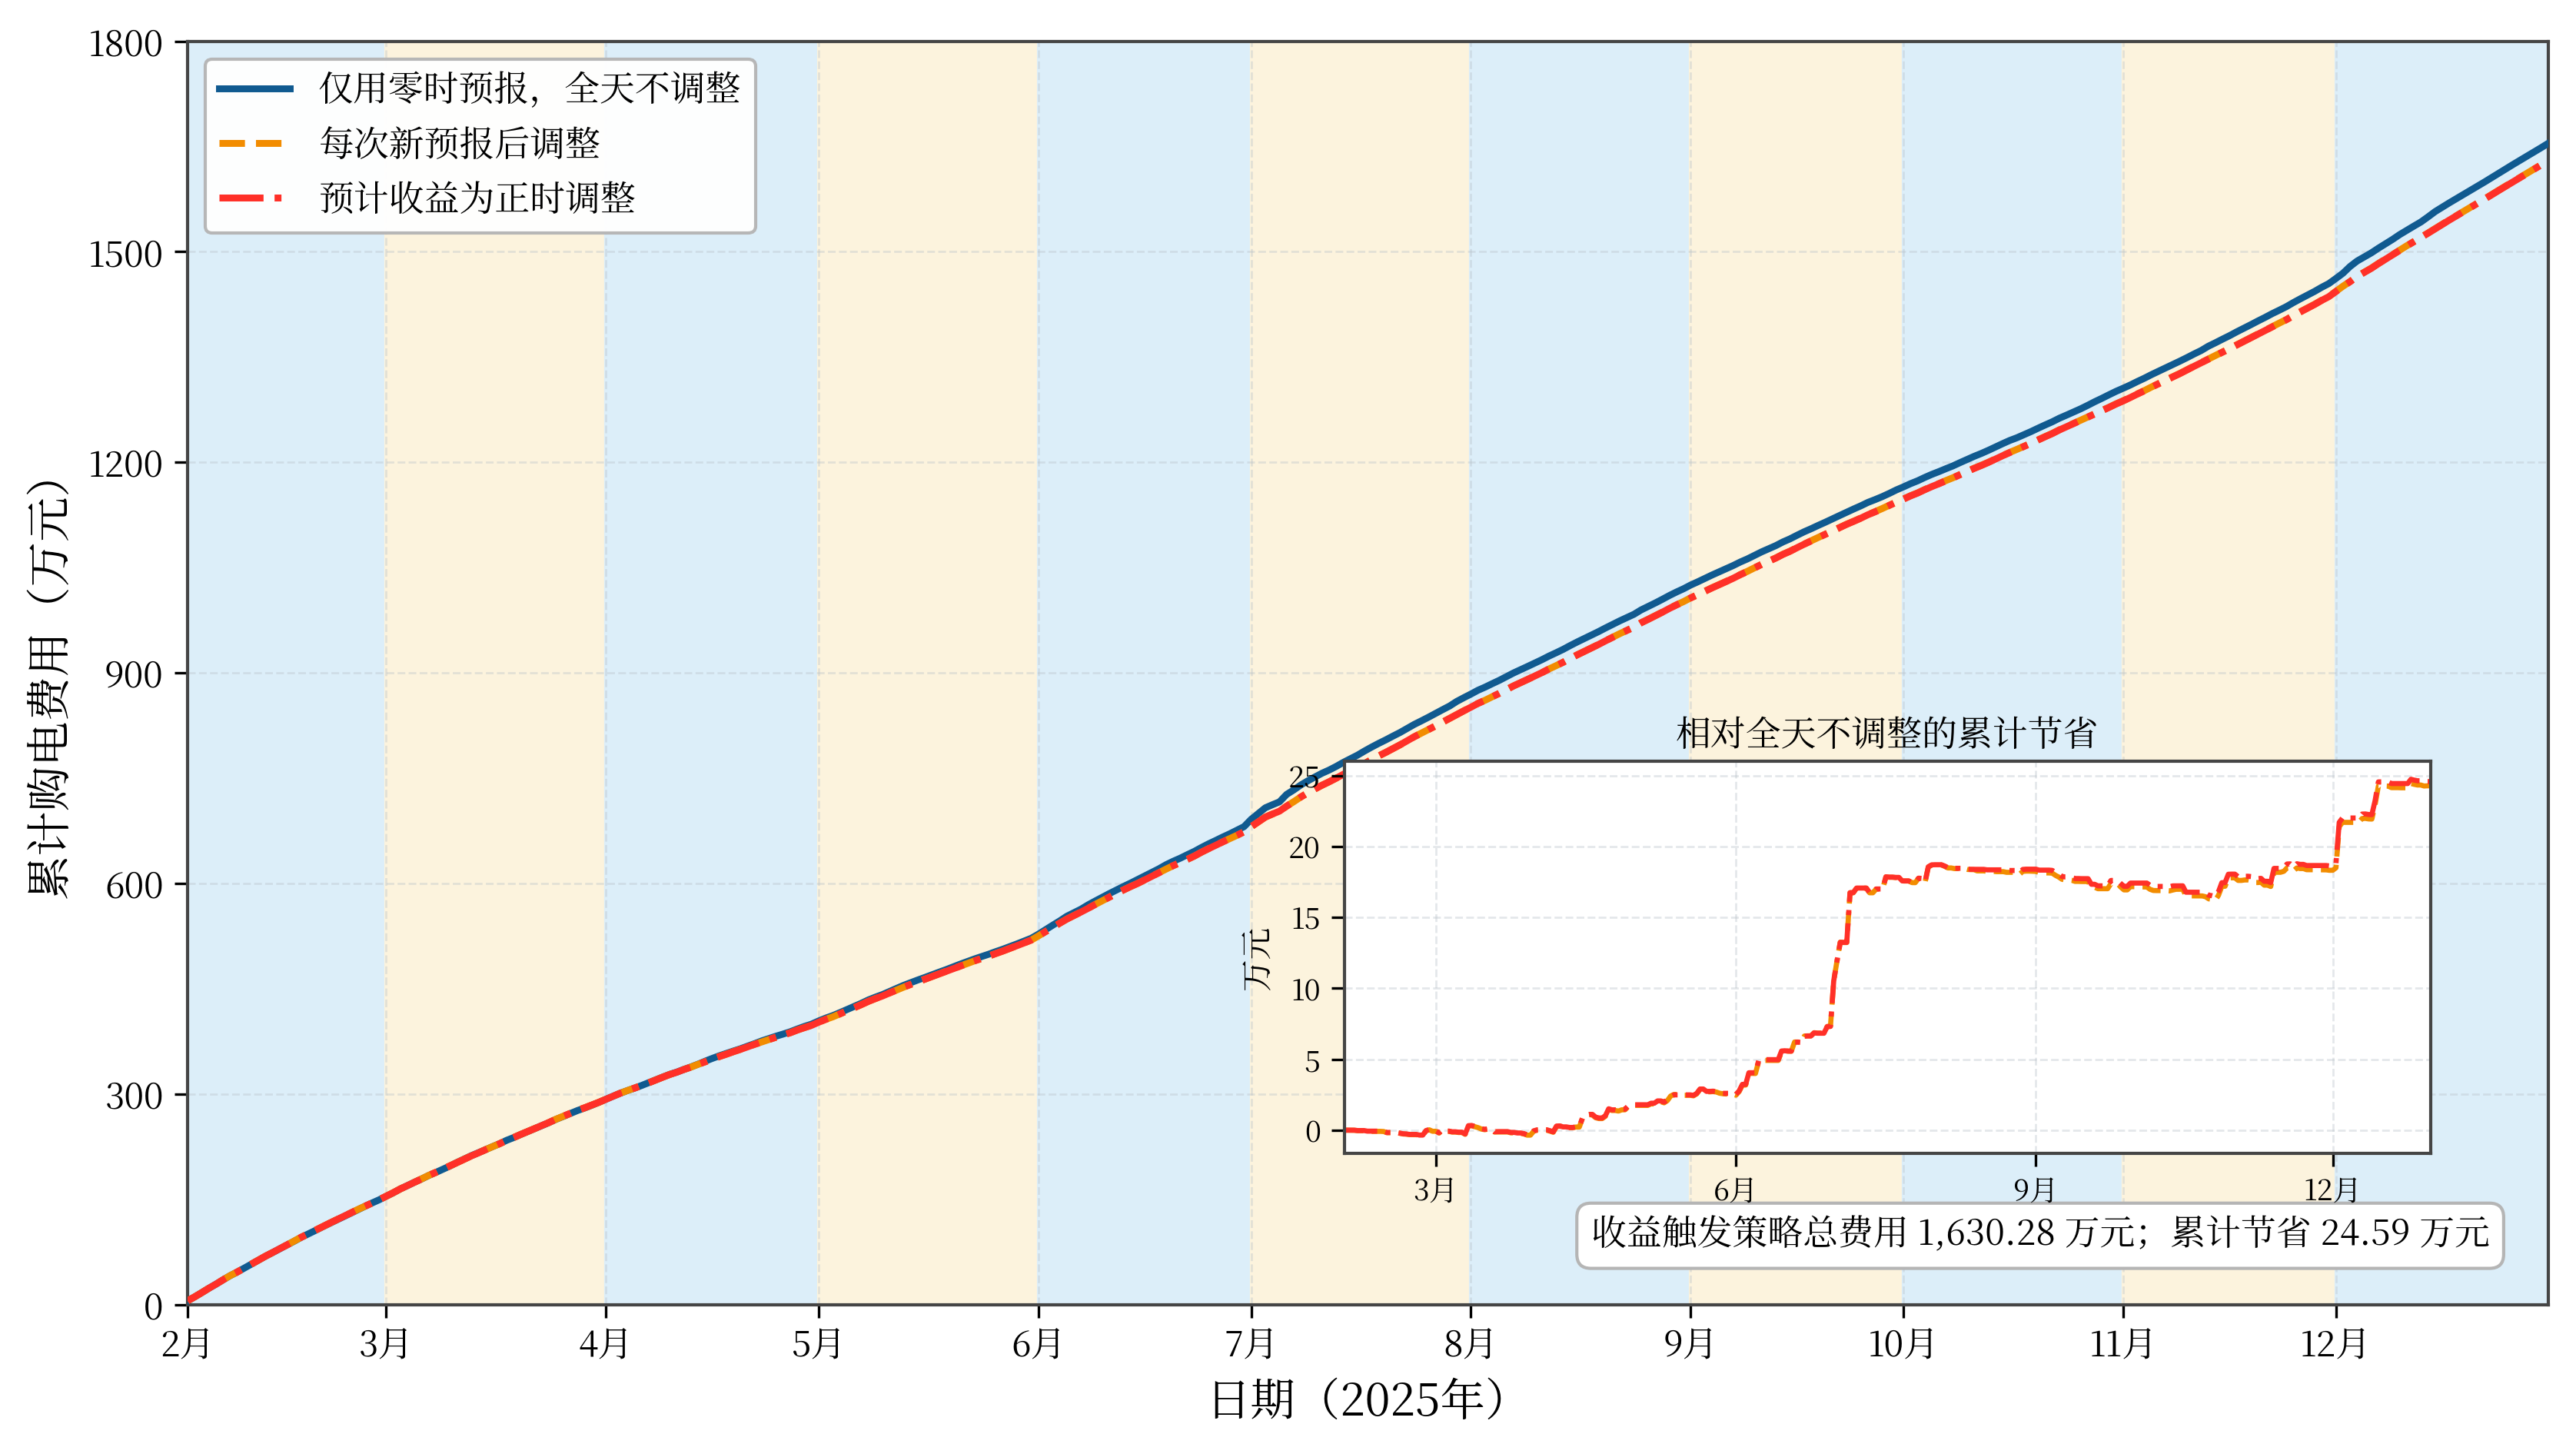

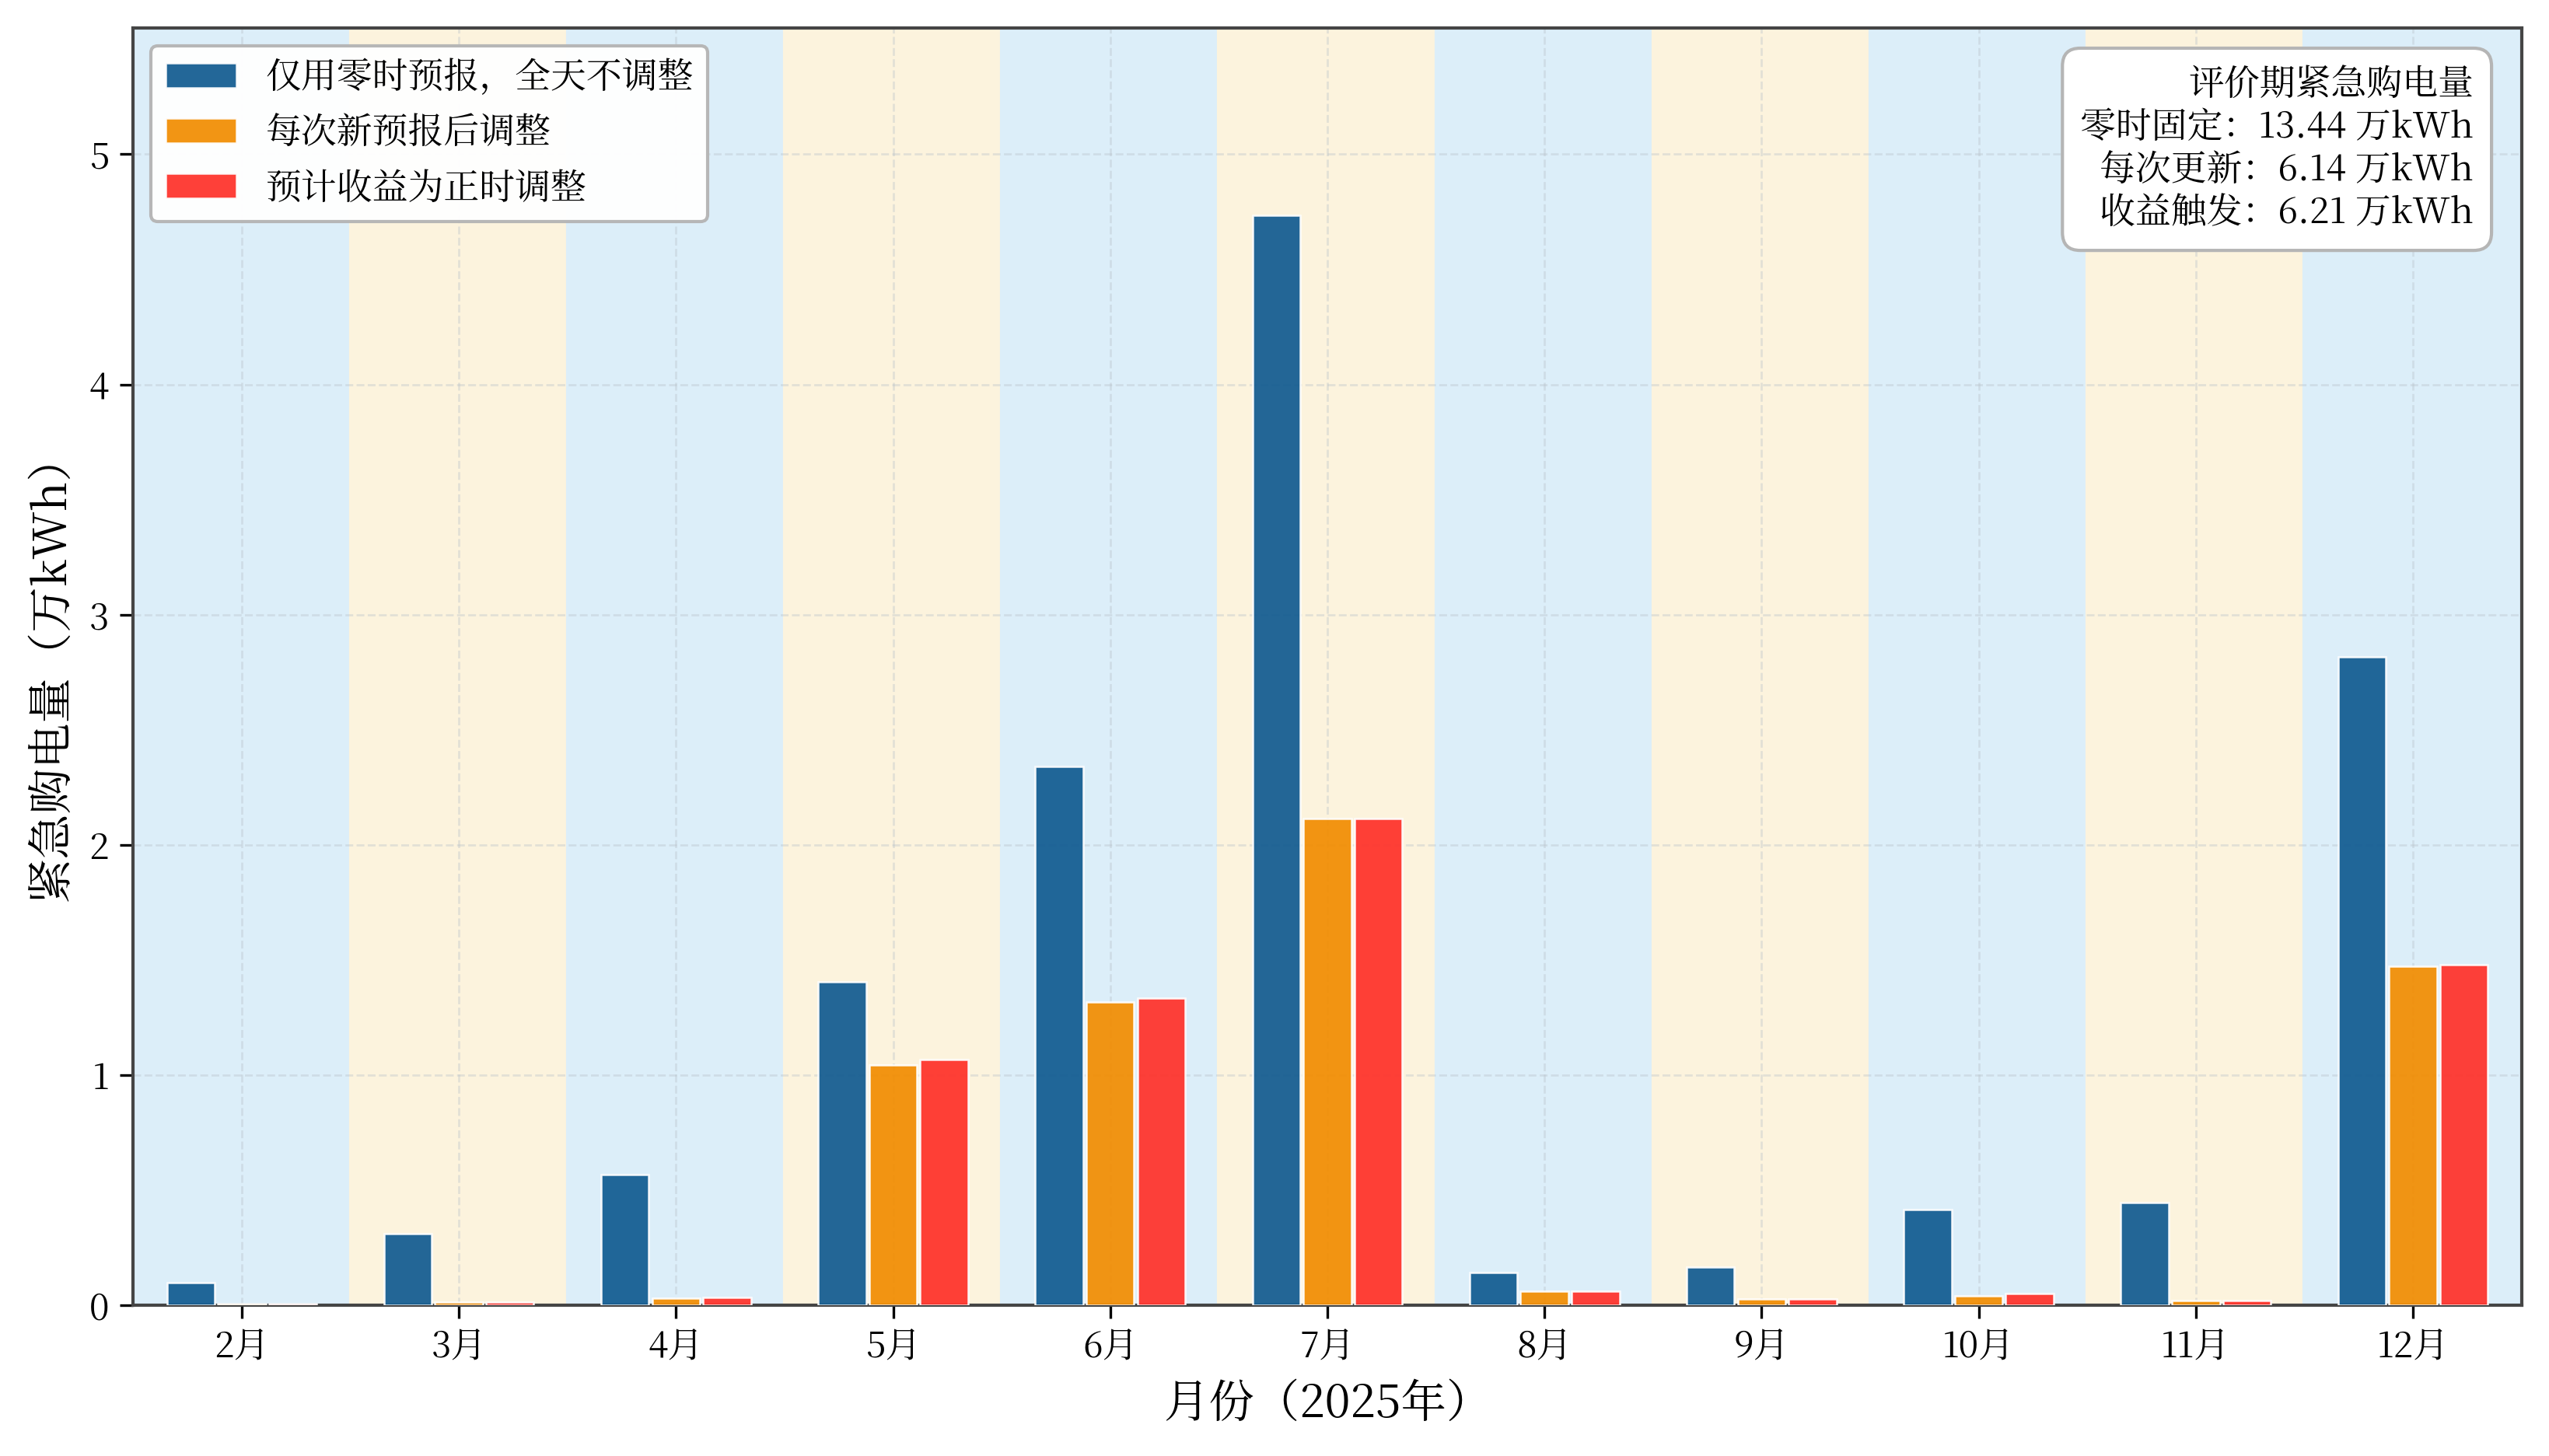

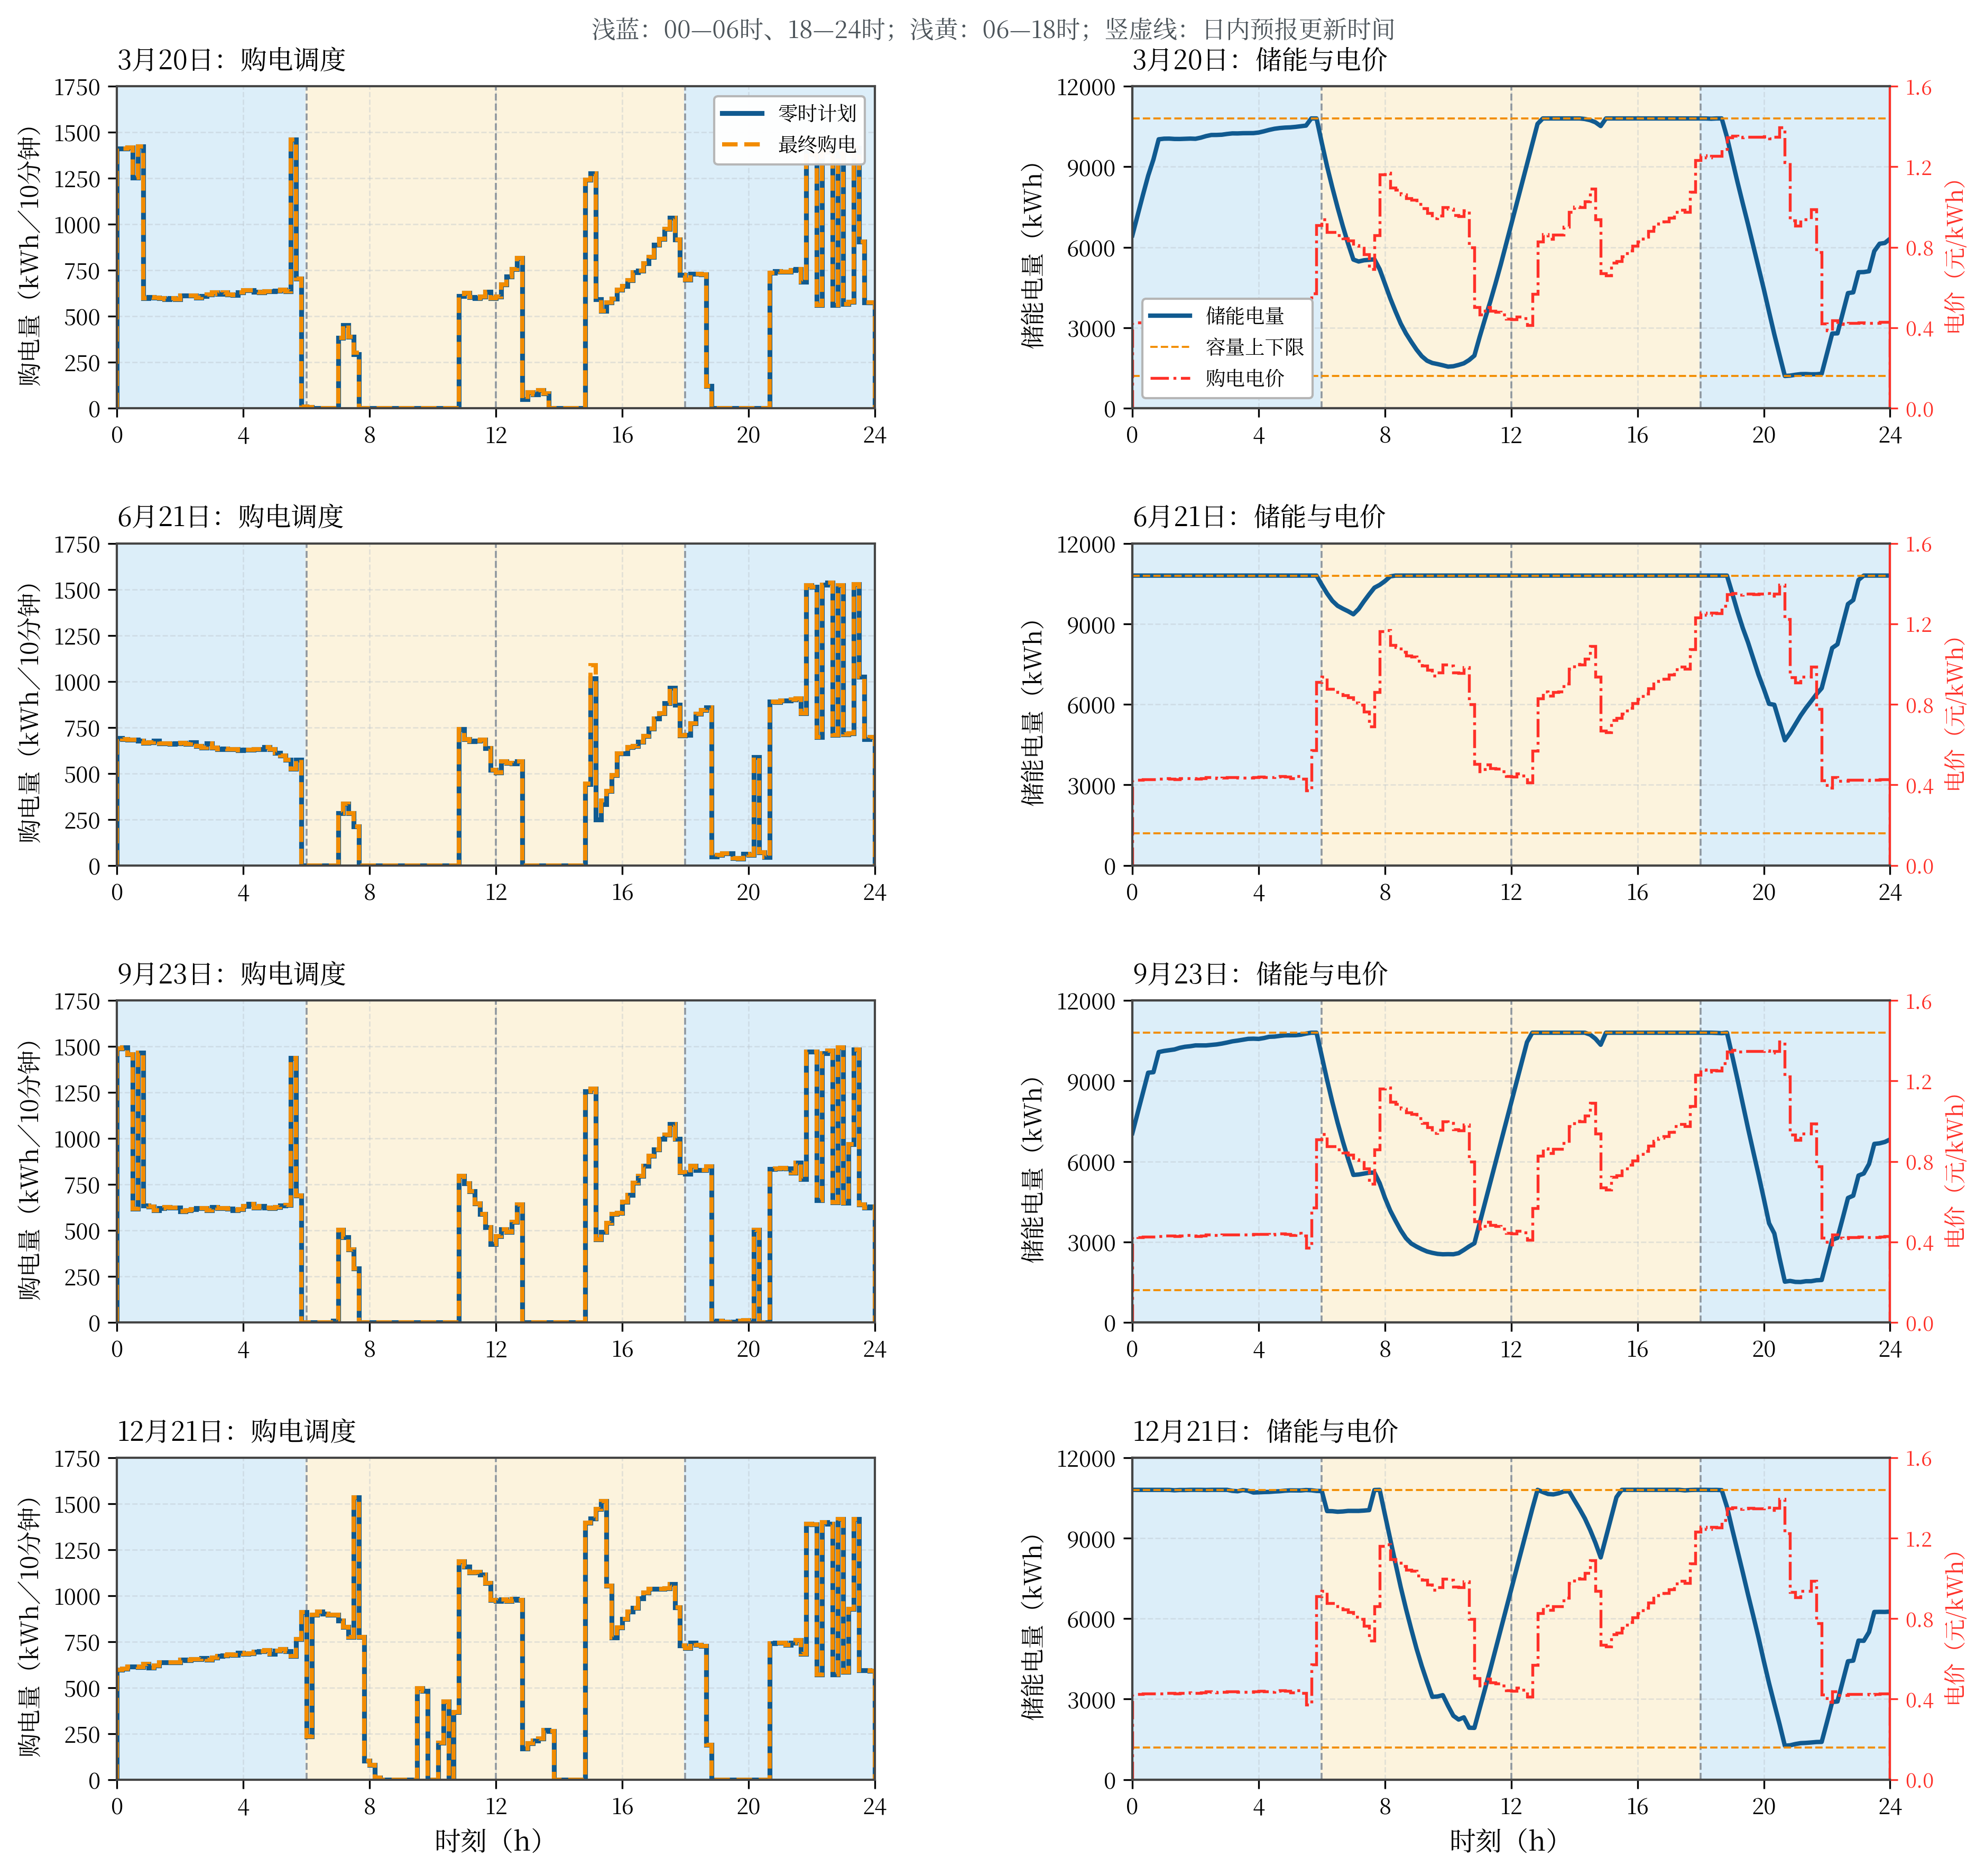

In [ ]:
"""Chinese Q3 figures. Run: python draw_q3_chinese.py [project_directory].
No optimisation or filtering changes. PNG + vector PDF, no bottom captions.
"""
from pathlib import Path
import sys,json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib import font_manager,dates as mdates
from matplotlib.ticker import MultipleLocator,FuncFormatter

METHODS_PLOT=['forecast00_fixed','forecast_updates','benefit_trigger']
LABELS_PLOT=['仅用零时预报，全天不调整','每次新预报后调整','预计收益为正时调整']
BLUE='#105A90';ORANGE='#F28C00';RED='#FF3028'
SKY='#DCEEF9';CREAM='#FCF3DD';INK='#333333'


def configure_style():
    for directory in [Path.home()/'.local/share/fonts',Path('C:/Windows/Fonts')]:
        if directory.exists():
            for p in directory.glob('*'):
                if p.suffix.lower() in ['.ttf','.ttc','.otf']:
                    try:font_manager.fontManager.addfont(str(p))
                    except (OSError,RuntimeError):pass
    names={f.name for f in font_manager.fontManager.ttflist}
    selected=[s for s in ['SimSun','STSong','Songti SC','Noto Serif CJK SC','Microsoft YaHei','Noto Sans CJK SC','SimHei'] if s in names]
    if not selected:raise RuntimeError('未找到中文字体，请安装宋体、微软雅黑或Noto Sans CJK SC。')
    plt.rcParams.update({'font.family':'serif','font.serif':selected+['DejaVu Serif'],
      'font.sans-serif':selected+['DejaVu Sans'],'axes.unicode_minus':False,
      'font.size':12,'axes.labelsize':14,'axes.titlesize':13,'legend.fontsize':11,
      'xtick.labelsize':11,'ytick.labelsize':11,'axes.edgecolor':'#454545','axes.linewidth':1.0,
      'axes.axisbelow':True,'grid.linestyle':'--','grid.linewidth':.65,'grid.alpha':.38,
      'grid.color':'#B8C1C8','legend.frameon':True,'legend.facecolor':'white',
      'legend.edgecolor':'#B5B5B5','legend.framealpha':.97,'figure.facecolor':'white',
      'savefig.facecolor':'white','pdf.fonttype':42,'ps.fonttype':42})


def style_axes(ax):
    ax.set_facecolor(CREAM);ax.grid(True);ax.tick_params(direction='out',length=4,width=.8)


def save_figure(fig,out,name):
    paths=[]
    for ext in ['png','pdf']:
        path=Path(out)/(name+'.'+ext);fig.savefig(path,dpi=300,bbox_inches='tight',pad_inches=.12);paths.append(str(path))
    plt.close(fig);return paths


def plot_q3_figures(frames,out):
    configure_style();out=Path(out);out.mkdir(parents=True,exist_ok=True)
    xs={}
    for name in METHODS_PLOT:
        x=frames[name].copy();x['date']=pd.to_datetime(x.date)
        x=x[(x.date>=pd.Timestamp('2025-02-01'))&(x.date<=pd.Timestamp('2025-12-31'))]
        assert len(x)==334*144 and x.groupby('date').size().eq(144).all()
        xs[name]=x
    daily={m:x.groupby('date').total_cost_yuan.sum().sort_index() for m,x in xs.items()}
    cumulative={m:x.cumsum()/10000 for m,x in daily.items()}
    totals={m:float(x.sum()) for m,x in daily.items()}
    savings=(totals[METHODS_PLOT[0]]-totals[METHODS_PLOT[2]])/10000
    colors=[BLUE,ORANGE,RED];linestyles=['-','--','-.'];paths=[]
    # Figure 1: calendar scale; shading means alternating months, never day/night.
    fig,ax=plt.subplots(figsize=(11.7,6.6));fig.subplots_adjust(left=.10,right=.975,bottom=.13,top=.96)
    style_axes(ax)
    bounds=pd.date_range('2025-02-01','2026-01-01',freq='MS')
    for i in range(11):ax.axvspan(bounds[i],bounds[i+1],color=SKY if i%2==0 else CREAM,zorder=0)
    for name,label,col,ls in zip(METHODS_PLOT,LABELS_PLOT,colors,linestyles):
        ax.plot(cumulative[name].index,cumulative[name],color=col,ls=ls,lw=2.15,label=label,zorder=3)
    ax.set_xlim(pd.Timestamp('2025-02-01'),pd.Timestamp('2025-12-31'));ax.set_ylim(0,1800)
    ax.set_ylabel('累计购电费用（万元）');ax.set_xlabel('日期（2025年）')
    ax.xaxis.set_major_locator(mdates.MonthLocator());ax.xaxis.set_major_formatter(FuncFormatter(lambda v,p:f'{mdates.num2date(v).month}月'))
    ax.yaxis.set_major_locator(MultipleLocator(300));ax.legend(loc='upper left')
    inset=ax.inset_axes([.49,.12,.46,.31]);style_axes(inset);inset.set_facecolor('white')
    for name,col,ls in zip(METHODS_PLOT[1:],colors[1:],linestyles[1:]):
        delta=cumulative[METHODS_PLOT[0]]-cumulative[name]
        inset.plot(delta.index,delta,color=col,ls=ls,lw=1.6)
    inset.set_title('相对全天不调整的累计节省',fontsize=11,pad=5)
    inset.set_ylabel('万元',fontsize=10);inset.tick_params(labelsize=9)
    inset.set_xlim(pd.Timestamp('2025-02-01'),pd.Timestamp('2025-12-31'))
    inset.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[3,6,9,12]));inset.xaxis.set_major_formatter(FuncFormatter(lambda v,p:f'{mdates.num2date(v).month}月'))
    ax.text(.975,.04,f'收益触发策略总费用 {totals[METHODS_PLOT[2]]/10000:,.2f} 万元；累计节省 {savings:.2f} 万元',
      transform=ax.transAxes,ha='right',va='bottom',fontsize=11,bbox=dict(boxstyle='round,pad=.4',fc='white',ec='#B5B5B5'))
    paths+=save_figure(fig,out,'01_cost')
    # Figure 2: exact monthly sums. Month backgrounds carry no solar meaning.
    fig,ax=plt.subplots(figsize=(11.7,6.6));fig.subplots_adjust(left=.10,right=.975,bottom=.13,top=.96)
    style_axes(ax);months=np.arange(2,13)
    for i,month in enumerate(months):ax.axvspan(month-.5,month+.5,color=SKY if i%2==0 else CREAM,zorder=0)
    annual=[]
    for i,(name,label,col) in enumerate(zip(METHODS_PLOT,LABELS_PLOT,colors)):
        x=xs[name];values=x.groupby(x.date.dt.month).emergency_kwh.sum().reindex(months).to_numpy()/10000
        assert np.isclose(values.sum()*10000,x.emergency_kwh.sum())
        annual.append(values.sum());ax.bar(months+(i-1)*.235,values,width=.22,color=col,alpha=.92,
             edgecolor='white',lw=.6,label=label,zorder=3)
    ax.set_xlim(1.5,12.5);ax.set_xticks(months,[f'{m}月' for m in months]);ax.set_ylim(0,5.55)
    ax.set_xlabel('月份（2025年）');ax.set_ylabel('紧急购电量（万kWh）');ax.legend(loc='upper left')
    ax.text(.98,.97,'评价期紧急购电量\n'+f'零时固定：{annual[0]:.2f} 万kWh\n每次更新：{annual[1]:.2f} 万kWh\n收益触发：{annual[2]:.2f} 万kWh',
      transform=ax.transAxes,ha='right',va='top',fontsize=11,bbox=dict(boxstyle='round,pad=.5',fc='white',ec='#B5B5B5'))
    paths+=save_figure(fig,out,'02_emergency')
    # Figure 3: full 0..24h trajectories; storage includes the 24:00 boundary.
    fig,axs=plt.subplots(4,2,figsize=(13,12.2));fig.subplots_adjust(left=.075,right=.935,bottom=.07,top=.945,hspace=.42,wspace=.34)
    selected=['2025-03-20','2025-06-21','2025-09-23','2025-12-21'];primary=xs['benefit_trigger']
    for row,day in enumerate(selected):
        x=primary[primary.date.eq(pd.Timestamp(day))].sort_values('slot');assert len(x)==144
        edges=np.arange(145)/6;left,right=axs[row]
        for a in [left,right]:
            style_axes(a);a.axvspan(0,6,color=SKY,zorder=0);a.axvspan(6,18,color=CREAM,zorder=0);a.axvspan(18,24,color=SKY,zorder=0)
            for h in [6,12,18]:a.axvline(h,color='#8E969E',ls='--',lw=.85,zorder=1)
            a.set_xlim(0,24);a.xaxis.set_major_locator(MultipleLocator(4));a.tick_params(labelsize=10)
        stamp=f'{pd.Timestamp(day).month}月{pd.Timestamp(day).day}日'
        left.stairs(x.planned_grid_kwh.to_numpy(),edges,color=BLUE,lw=2.2,label='零时计划')
        left.stairs(x.adjusted_grid_kwh.to_numpy(),edges,color=ORANGE,ls='--',lw=1.9,label='最终购电')
        left.set_ylim(0,1750);left.set_ylabel('购电量（kWh／10分钟）',fontsize=11)
        left.set_title(stamp+'：购电调度',loc='left',fontsize=12,pad=8)
        state=np.r_[x.storage_start_kwh.iloc[0],x.storage_end_kwh.to_numpy()]
        right.plot(edges,state,color=BLUE,lw=2,label='储能电量')
        for val in [1200,10800]:right.axhline(val,color=ORANGE,ls='--',lw=.9,label='容量上下限' if val==1200 else None)
        right.set_ylim(0,12000);right.yaxis.set_major_locator(MultipleLocator(3000));right.set_ylabel('储能电量（kWh）',fontsize=11)
        right.set_title(stamp+'：储能与电价',loc='left',fontsize=12,pad=8)
        price_ax=right.twinx();price_ax.stairs(x.price.to_numpy(),edges,color=RED,ls='-.',lw=1.3,label='购电电价')
        price_ax.set_ylim(0,1.6);price_ax.yaxis.set_major_locator(MultipleLocator(.4))
        price_ax.set_ylabel('电价（元/kWh）',color=RED,fontsize=10);price_ax.tick_params(axis='y',colors=RED,labelsize=9);price_ax.spines['right'].set_color(RED);price_ax.grid(False)
        if row==0:
            left.legend(loc='upper right',fontsize=9)
            h1,l1=right.get_legend_handles_labels();h2,l2=price_ax.get_legend_handles_labels()
            price_ax.legend(h1+h2,l1+l2,loc='lower left',fontsize=9,framealpha=1.0)
        if row==3:
            for a in [left,right]:a.set_xlabel('时刻（h）',fontsize=12)
    # Top key is inside the figure; no extra bottom caption.
    fig.text(.50,.98,'浅蓝：00—06时、18—24时；浅黄：06—18时；竖虚线：日内预报更新时间',ha='center',va='top',fontsize=11,color='#4D555B')
    paths+=save_figure(fig,out,'03_selected_days')
    metrics={'total_cost_yuan':totals,'benefit_trigger_saving_yuan':savings*10000,
      'emergency_kwh':{m:float(xs[m].emergency_kwh.sum()) for m in METHODS_PLOT},
      'period':'2025-02-01 to 2025-12-31','daily_plot_boundary_count':145,
      'background_note':'Calendar plots alternate months; intraday plots distinguish 00–06/06–18/18–24, not sunrise/sunset.'}
    (out/'figure_metrics.json').write_text(json.dumps(metrics,ensure_ascii=False,indent=2),encoding='utf-8')
    return paths


plot_q3_figures({m:results[m][0] for m in METHODS_PLOT},OUT/'figures')
try:
    from IPython.display import Image
except ImportError:
    Image=lambda filename:Path(filename)
for filename in ['01_cost.png','02_emergency.png','03_selected_days.png']:
    display(Image(filename=str(OUT/'figures'/filename)))

In [ ]:
def clock(minute):return f'{minute//60:02d}:{minute%60:02d}'

def emergency_events(dispatch):
    rows=[]
    for day,x in dispatch.groupby('date',sort=True):
        x=x.sort_values('slot'); a=x.emergency_kwh.to_numpy(); t=0
        while t<len(a):
            if a[t]<=1e-6: t+=1;continue
            start=t
            while t<len(a) and a[t]>1e-6:t+=1
            rows.append(dict(date=day,interval=f'{clock(start*10)}-{clock(t*10)}',
                             emergency_kwh=float(a[start:t].sum()),start_slot=start+1,end_slot=t))
    return pd.DataFrame(rows,columns=['date','interval','emergency_kwh','start_slot','end_slot'])

In [ ]:
main=results['benefit_trigger'][0]
selected=['2025-03-20','2025-06-21','2025-09-23','2025-12-21']
for day in selected:
    x=main[main.date.eq(day)]
    print(day)
    display(x[x.slot.isin([61,73,85,97,109,121])][['interval_start','planned_grid_kwh','adjusted_grid_kwh']])
    print('Daily costs:',x[['planned_cost_yuan','adjustment_cost_yuan','emergency_cost_yuan','total_cost_yuan']].sum().to_dict())
    print('Initial/final battery:',x.storage_start_kwh.iloc[0],x.storage_end_kwh.iloc[-1])
    display(emergency_events(x))
print('Q3 NOTEBOOK: PASS')

2025-03-20
Daily costs: {'planned_cost_yuan': 44091.832024863455, 'adjustment_cost_yuan': 10.22548508083342, 'emergency_cost_yuan': 108.89222079998184, 'total_cost_yuan': 44210.949730744265}
Initial/final battery: 6444.900804444449 6316.293224259261
2025-06-21
Daily costs: {'planned_cost_yuan': 43981.841796850145, 'adjustment_cost_yuan': 149.6631652797633, 'emergency_cost_yuan': 0.0, 'total_cost_yuan': 44131.50496212991}
Initial/final battery: 10800.0 10800.0
2025-09-23
Daily costs: {'planned_cost_yuan': 47081.48079671156, 'adjustment_cost_yuan': 0.0, 'emergency_cost_yuan': 42.996187500000005, 'total_cost_yuan': 47124.476984211564}
Initial/final battery: 7058.966817777778 6820.97436074074
2025-12-21
Daily costs: {'planned_cost_yuan': 59206.094495829515, 'adjustment_cost_yuan': 0.0, 'emergency_cost_yuan': 31.579071950000504, 'total_cost_yuan': 59237.673567779515}
Initial/final battery: 10800.0 6260.76220611111
Q3 NOTEBOOK: PASS


,interval_start,planned_grid_kwh,adjusted_grid_kwh
11292,2025-03-20 10:00:00,0.0000,0.0000
11304,2025-03-20 12:00:00,604.9616,604.9616
11316,2025-03-20 14:00:00,0.0000,0.0000
11328,2025-03-20 16:00:00,664.3627,664.3627
11340,2025-03-20 18:00:00,697.3552,697.3552
11352,2025-03-20 20:00:00,0.0000,0.0000


,date,interval,emergency_kwh,start_slot,end_slot
0,2025-03-20,20:30-20:40,15.6095,124,124


,interval_start,planned_grid_kwh,adjusted_grid_kwh
24684,2025-06-21 10:00:00,0.0000,0.0000
24696,2025-06-21 12:00:00,503.9828,503.9828
24708,2025-06-21 14:00:00,0.0000,0.0000
24720,2025-06-21 16:00:00,606.6250,606.6250
24732,2025-06-21 18:00:00,708.6660,708.6660
24744,2025-06-21 20:00:00,56.3979,56.3979


,date,interval,emergency_kwh,start_slot,end_slot


,interval_start,planned_grid_kwh,adjusted_grid_kwh
38220,2025-09-23 10:00:00,0.0000,0.0000
38232,2025-09-23 12:00:00,469.4574,469.4574
38244,2025-09-23 14:00:00,0.0000,0.0000
38256,2025-09-23 16:00:00,655.7885,655.7885
38268,2025-09-23 18:00:00,808.0662,808.0662
38280,2025-09-23 20:00:00,0.0000,0.0000


,date,interval,emergency_kwh,start_slot,end_slot
0,2025-09-23,20:20-20:30,6.3750,123,123


,interval_start,planned_grid_kwh,adjusted_grid_kwh
51036,2025-12-21 10:00:00,0.0000,0.0000
51048,2025-12-21 12:00:00,970.0151,970.0151
51060,2025-12-21 14:00:00,0.0000,0.0000
51072,2025-12-21 16:00:00,873.9510,873.9510
51084,2025-12-21 18:00:00,715.6143,715.6143
51096,2025-12-21 20:00:00,0.0000,0.0000


,date,interval,emergency_kwh,start_slot,end_slot
0,2025-12-21,07:50-08:00,5.4367,48,48


## 11. 解释边界

结果支持本次回测下引入日内预报，但收益触发相对每次更新的改善很小，不宜夸大。原模板时间标题及减购退费规则尚需确认。当前策略没有用到跨午夜预报，没有把计划与实时控制统一求解，也未证明全局最优。完整Markdown报告含4小时储能表及全部指定日期结果。

修改参数后，Notebook导出的CSV是新结果；交付Excel、Markdown报告为默认参数快照，需用完整包的导出流程更新。